# Day 19 of ML 30-Days Challenge

# Task

**Naive Bayes**: Learn the probabilistic classification method based on Bayes' theorem. Understand the "naive" assumption of conditional independence among features and why this model still performs surprisingly well, especially for text classification.

In [33]:
import random
import numpy as np
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

###Why use TSV instead of CSV?
I obtained the CSV dataset of ham/spam messages from [Kaggle](https://www.kaggle.com/datasets/bagavathypriya/spam-ham-dataset) {<-Unrefined Dataset Link Here}. Because commas within the text columns were causing splitting issues, I converted the dataset to a TSV (tab-separated values) file to handle this.

###1. Use this code refine it from any of queries. 😤

In [34]:
INPUT_CSV = "/content/spamhamdata.csv"
CLEAN_TSV = "spam_ham_clean.tsv"

label_re = re.compile(r"^\s*(spam|ham)\b\s*[:,-]?\s*(.*)$", flags=re.IGNORECASE)

rows = []

with open(INPUT_CSV, "r", encoding="utf-8", errors="ignore") as f:
    for raw in f:
        s = raw.strip()
        if not s:
            continue
        m = label_re.match(s)
        if not m:
            continue
        label = m.group(1).lower()
        text = m.group(2)

        text = text.strip()
        if len(text) >= 2 and ((text[0] == '"' and text[-1] == '"') or (text == "'" and text[-1] == "'")):
            text = text[1:-1]
        text = text.lstrip()

        rows.append((label, text))

df = pd.DataFrame(rows, columns=["label", "text"])
df = df[df["text"].str.len() > 0].drop_duplicates().reset_index(drop=True)

# Save once as TSV (tabs aren’t affected by commas in text)
df.to_csv(CLEAN_TSV, sep="\t", index=False)

print(f"Saved tab-separated file: {CLEAN_TSV}")

Saved tab-separated file: spam_ham_clean.tsv


In [35]:
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


###2. Train-test split

In [36]:
X_train, X_test, y_train, y_test = train_test_split( df["text"], df["label"], test_size=0.25, random_state=42, stratify=df["label"] )

X_train.head()

,text
2957,Stop knowing me so well!
5013,Yup he msg me: is tat yijue? Then i tot it's m...
748,"We are at grandmas. Oh dear, u still ill? I fe..."
3755,K...k...when will you give treat?
3435,Carlos says we can pick up from him later so y...


###3. Build Pipeline: CountVectorizer + MultinomialNB

In [37]:
pipe = Pipeline([
    ("vect", CountVectorizer()),
    ("nb", MultinomialNB())
])

###4. Train

In [38]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('vect', CountVectorizer()), ('nb', MultinomialNB())])

###5. Evaluate

In [39]:
y_pred = pipe.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc:.3f}\n") # That's Why data cleaning and refining is important.
print(classification_report(y_test, y_pred))

Accuracy: 0.983

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99      1130
        spam       0.96      0.90      0.93       160

    accuracy                           0.98      1290
   macro avg       0.97      0.95      0.96      1290
weighted avg       0.98      0.98      0.98      1290



###6. Visualize on one graph: confusion matrix heatmap (Pretty Much optional, just to end the day)

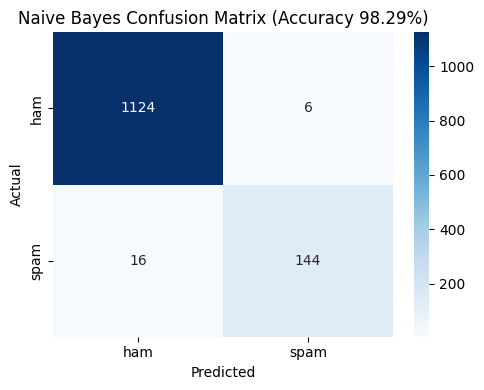

In [40]:
cm = confusion_matrix(y_test, y_pred, labels=["ham", "spam"])

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
plt.title(f"Naive Bayes Confusion Matrix (Accuracy {acc:.2%})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()